In [1]:
import sys
print(sys.executable)

/mnt/c/Users/ssait/Desktop/learnings/python-practice-jupyter/venv/bin/python


In [20]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("/mnt/c/Users/ssait/Downloads/anime_data.csv")

Data Overview 

In [5]:
df.head()

,title,description,mediaType,eps,duration,ongoing,sznOfRelease,years_running,studio_primary,studios_colab,...,tag_Supernatural,tag_Magic,tag_Animal_Protagonists,tag_Ecchi,tag_Mecha,tag_Based_on_a_Light_Novel,tag_CG_Animation,tag_Superpowers,tag_Others,tag_missing
0,Fullmetal Alchemist: Brotherhood,The foundation of alchemy is based on the law ...,TV,64,NaN,False,Spring,1,Bones,0,...,0,0,0,0,0,0,0,0,0,0
1,your name.,Mitsuha and Taki are two total strangers livin...,Movie,1,107.0,False,is_missing,0,Others,0,...,1,0,0,0,0,0,0,0,0,0
2,A Silent Voice,"After transferring into a new school, a deaf g...",Movie,1,130.0,False,is_missing,0,Kyoto Animation,0,...,0,0,0,0,0,0,0,0,0,0
3,Haikyuu!! Karasuno High School vs Shiratorizaw...,"Picking up where the second season ended, the ...",TV,10,NaN,False,Fall,0,Production I.G,0,...,0,0,0,0,0,0,0,0,0,0
4,Attack on Titan 3rd Season: Part II,The battle to retake Wall Maria begins now! Wi...,TV,10,NaN,False,Spring,0,Others,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(12101, 44)

There are 12101 rows and 44 columns.

In [8]:
data = df.copy()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12101 entries, 0 to 12100
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       12101 non-null  object 
 1   description                 7633 non-null   object 
 2   mediaType                   12101 non-null  object 
 3   eps                         12101 non-null  int64  
 4   duration                    7465 non-null   float64
 5   ongoing                     12101 non-null  bool   
 6   sznOfRelease                12101 non-null  object 
 7   years_running               12101 non-null  int64  
 8   studio_primary              12101 non-null  object 
 9   studios_colab               12101 non-null  int64  
 10  contentWarn                 12101 non-null  int64  
 11  watched                     12101 non-null  float64
 12  watching                    12101 non-null  int64  
 13  wantWatch                   121

* Dependent variable is the rating of an anime, which is of float type.
* title, description, mediaType, sznOfRelease, studio_primary are of object type.
* ongoing column is bool type.
* All other columns are numeric.
* There are missing values in description and duration.

In [10]:
data.duplicated().sum()

np.int64(0)

There are no duplicate values in the data.

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
eps,12101.0,13.393356,57.925097,1.000,1.000,2.000,12.000,2527.000
duration,7465.0,24.230141,31.468171,1.000,4.000,8.000,30.000,163.000
years_running,12101.0,0.283200,1.152234,0.000,0.000,0.000,0.000,51.000
studios_colab,12101.0,0.051649,0.221326,0.000,0.000,0.000,0.000,1.000
contentWarn,12101.0,0.115362,0.319472,0.000,0.000,0.000,0.000,1.000
watched,12101.0,2862.605694,7724.347024,0.000,55.000,341.000,2026.000,161567.000
watching,12101.0,256.334435,1380.840902,0.000,2.000,14.000,100.000,74537.000
wantWatch,12101.0,1203.681431,2294.327380,0.000,49.000,296.000,1275.000,28541.000
dropped,12101.0,151.568383,493.931710,0.000,3.000,12.000,65.000,19481.000
rating,12101.0,2.949037,0.827385,0.844,2.304,2.965,3.616,4.702


* We can see that the anime ratings vary between 0.844 to 4.702, which suggests that the anime were rated on scale of 5.
* 50% of the anime in the data has runtime less than or equal to 8mins.
* Atleast 75% of the anime have run for less than a year.
* Atleast 75% of the anime have no content warnings.
* The number of views for the anime has a wide range(0 to more than 160,000)

Checking for unique values in each column.

In [13]:
cat_columns = data.select_dtypes(exclude=np.number).columns
cat_columns

Index(['title', 'description', 'mediaType', 'ongoing', 'sznOfRelease',
       'studio_primary'],
      dtype='object')

In [14]:
# we will skip the title and description columns as they will have a lot of unique values
cat_col = ["mediaType", "ongoing", "sznOfRelease", "studio_primary"]

#printing the number of occurances of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

mediaType
TV             3993
Movie          1928
OVA            1770
Music Video    1290
Web            1170
DVD Special     803
Other           580
TV Special      504
is_missing       63
Name: count, dtype: int64
--------------------------------------------------
ongoing
False    11986
True       115
Name: count, dtype: int64
--------------------------------------------------
sznOfRelease
is_missing    8554
Spring        1135
Fall          1011
Winter         717
Summer         684
Name: count, dtype: int64
--------------------------------------------------
studio_primary
Others                  4340
is_missing              3208
Toei Animation           636
Sunrise                  430
J.C. Staff               341
MADHOUSE                 337
TMS Entertainment        317
Production I.G           271
Studio Deen              260
Studio Pierrot           221
OLM                      210
A-1 Pictures             194
AIC                      167
Shin-Ei Animation        164
Nippon Anima

* Most of the anime in the data are either TV series or movies.
* Most of the anime in the data are not ongoing.
* The season of release is missing for most of the anime in the data.
* Toei Animation and Sunrise are the top studios(excluding other studios and missing studios)

In [15]:
data.isnull().sum()

title                            0
description                   4468
mediaType                        0
eps                              0
duration                      4636
ongoing                          0
sznOfRelease                     0
years_running                    0
studio_primary                   0
studios_colab                    0
contentWarn                      0
watched                          0
watching                         0
wantWatch                        0
dropped                          0
rating                           0
votes                            0
tag_Based_on_a_Manga             0
tag_Comedy                       0
tag_Action                       0
tag_Fantasy                      0
tag_Sci_Fi                       0
tag_Shounen                      0
tag_Original_Work                0
tag_Non_Human_Protagonists       0
tag_Drama                        0
tag_Adventure                    0
tag_Family_Friendly              0
tag_Short_Episodes  

* duration and description has missing values 4636,4468 respectively.
* No other column has missing values.

We will drop the missing values in the dataset.

In [16]:
data.dropna(inplace=True)
data.shape

(3712, 44)

We will drop the title and description columns before moving forward as they have a lot of text in them.

In [22]:
data.drop(['title', 'description'], axis=1, inplace=True, errors='ignore')

Exploratory Data Analysis (EDA)

In [23]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12,7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True, # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )   # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette='winter'
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )

In [25]:
def labeled_barplot(data, feature, perc=False, n=None):

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

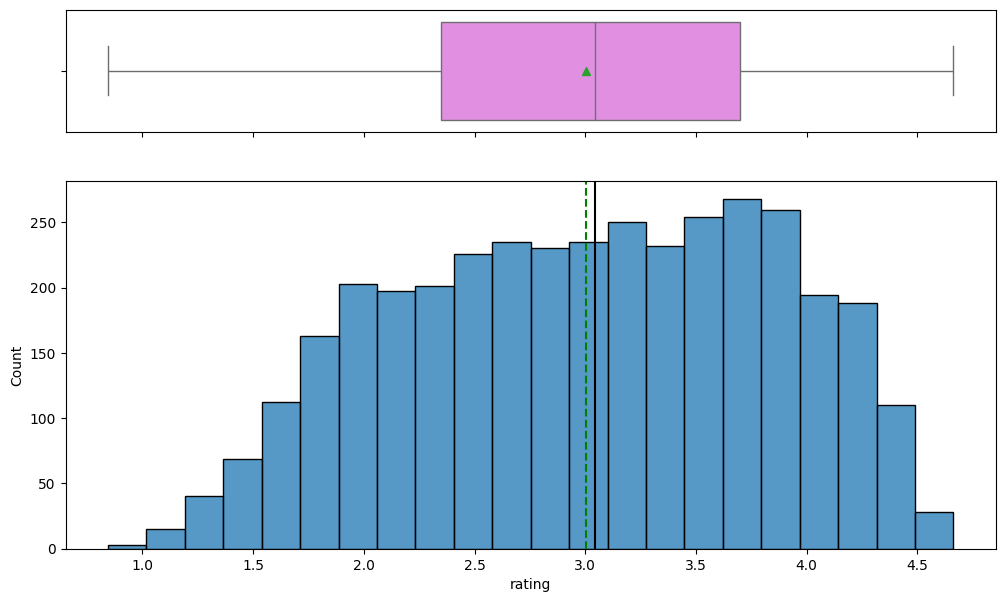

In [24]:
histogram_boxplot(data, "rating")

* The anime ratings are close to normally distributed.

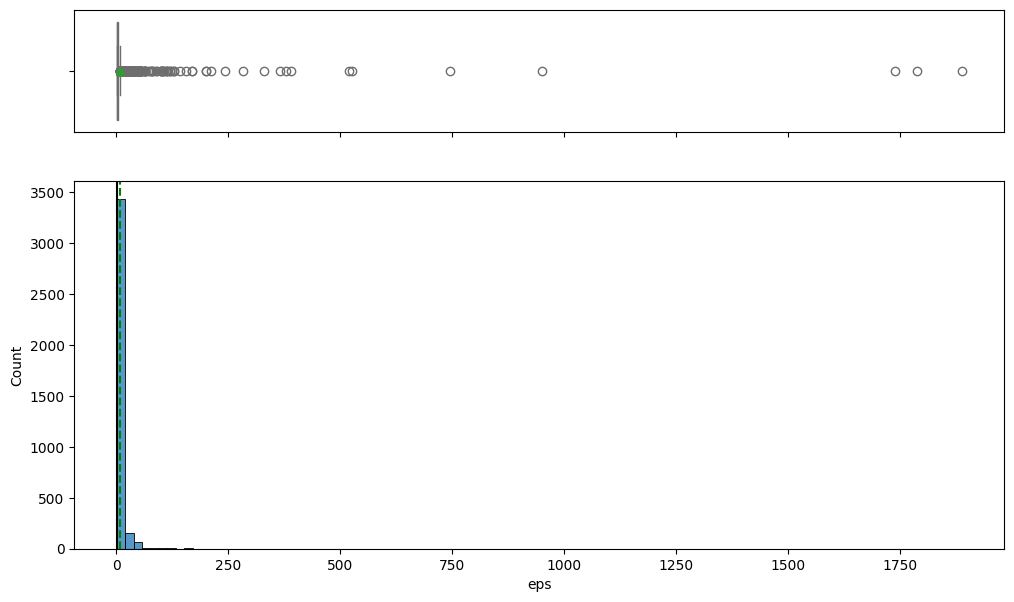

In [28]:
histogram_boxplot(data, "eps", bins=100)

* The distribution is heavily right-skewed, as there are many anime movies in the data, and they are considered to be of only one episode (as per data description).

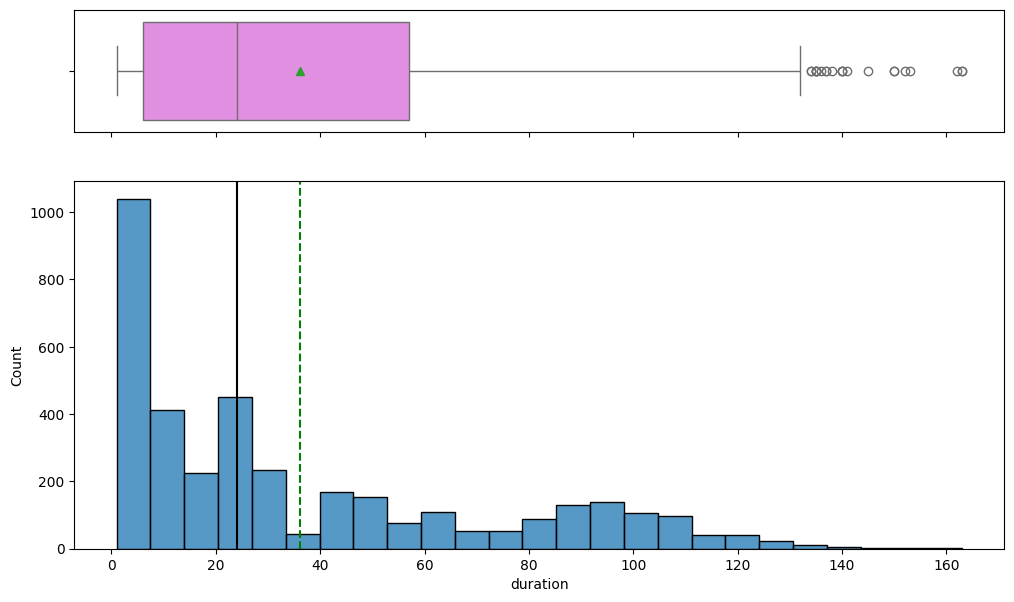

In [29]:
histogram_boxplot(data, "duration")

* The distribution is right-skewed.
* Majority of the data lies roughly between 0 and 40.
* Since outliers are present, using:
    * median and IQR is more reliable than:
    * mean and standard deviation


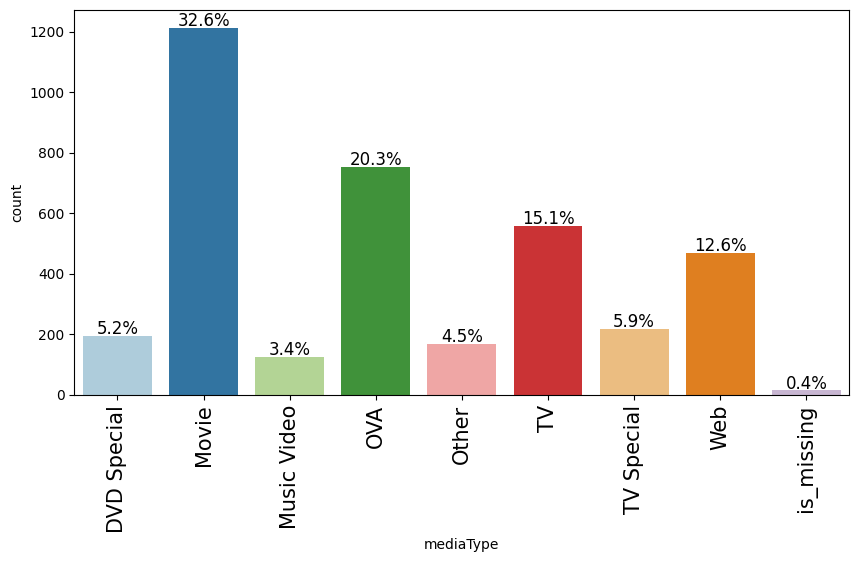

In [30]:
labeled_barplot(data, "mediaType", perc=True)

* Distribution of the media types has changed a lot after dropping the rows with missing values.
* Most of the anime now are movies or music videos.

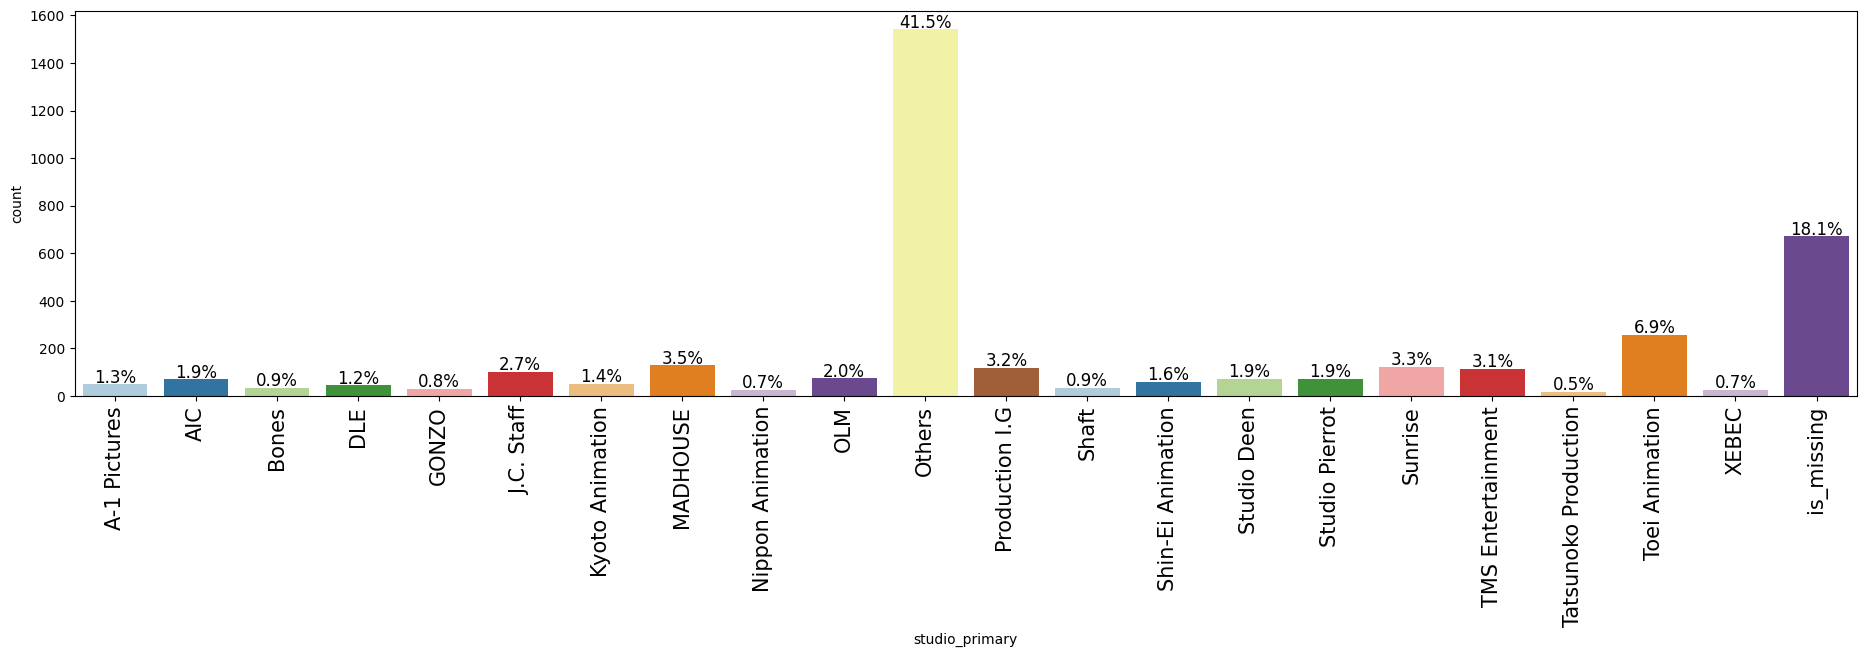

In [31]:
labeled_barplot(data, "studio_primary", perc=True)

* Toei Animation is the most common studio among the available studio names.

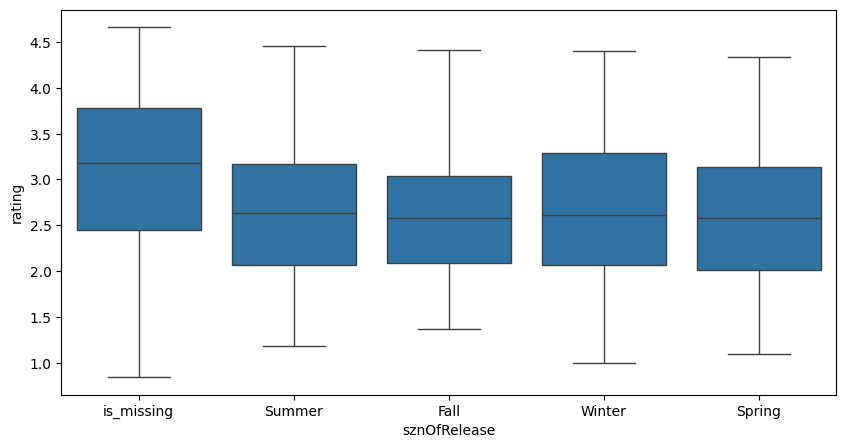

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="sznOfRelease", y="rating", data=data)
plt.show()

Anime ratings have a similar distribution across all the seasons of release.

Data Description:

The target variable (rating) is of float type.
title, description, mediaType, sznOfRelease, and studio_primary are of object type.
ongoing column is of bool type.
All other columns are numeric in nature.
The title and description columns are dropped for modeling as they are highly textual in nature.
There are no duplicate values in the data.
There are missing values in the data. The rows with missing data have been dropped.
Observations from EDA:

rating: The anime ratings are close to normally distributed, with a mean rating of 2.74. The rating increases with an increase in the number of people who have watched or want to watch the anime.
eps: The distribution is heavily right-skewed as there are many anime movies in the data (at least 50%), and they are considered to be of only one episode as per data description. The number of episodes increases as the anime runs for more years.
duration: The distribution is right-skewed with a median anime runtime of less than 10 minutes. With the increase in rating, the duration increases.
years_running: The distribution is heavily right-skewed, and at least 75% of the anime have run for less than 1 year.
watched: The distribution is heavily right-skewed, and most of the anime have less than 500 viewers. This attribute is highly correlated with the wantWatch and votes attributes.
watching: The distribution is heavily right-skewed and highly correlated with the dropped attribute.
wantWatch: The distribution is heavily right-skewed with a median value of 132 potential watchers.
dropped: The distribution is heavily right-skewed with a drop of 25 viewers on average.
votes: The distribution is heavily right-skewed, and few shows have more than 5000 votes.
mediaType: 23% of the anime are published for TV, 17% as music videos, and 14% as web series. Anime available as TV series, web series, or music videos have a lower rating in general
ongoing: Less than 1% of the anime in the data are ongoing.
sznOfRelease: The season of release is missing for nearly 90% of the anime in the data, and is spread out almost evenly across all seasons when available. Anime ratings have a similar distribution across all the seasons of release.
studio_primary: Nearly 40% of the anime in the data are produced by studios not listed in the data. Toei Animation is the most common studio among the available studio names. In general, the ratings are low for anime produced by DLE studios and studios other than the ones listed in the data.
studios_colab: More than 95% of the anime in the data do not involve collaboration between studios.
contentWarn: Less than 10% of the anime in the data have an associated content warning.
tag_<tag/genre>: There are 1747 anime that are based on manga, 1920 of the Comedy genre, 1238 of the Action genre, 1079 anime of the Romance genre, and more.

In [33]:
X = data.drop(['rating'], axis=1)
y = data['rating']

Creating dummy variables

In [35]:
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True
)
X.head()

,eps,duration,ongoing,years_running,studios_colab,contentWarn,watched,watching,wantWatch,dropped,...,studio_primary_Shaft,studio_primary_Shin-Ei Animation,studio_primary_Studio Deen,studio_primary_Studio Pierrot,studio_primary_Sunrise,studio_primary_TMS Entertainment,studio_primary_Tatsunoko Production,studio_primary_Toei Animation,studio_primary_XEBEC,studio_primary_is_missing
1,1,107.0,False,0,0,0,58831.0,1453,21733,124,...,False,False,False,False,False,False,False,False,False,False
2,1,130.0,False,0,0,1,45892.0,946,17148,132,...,False,False,False,False,False,False,False,False,False,False
8,1,111.0,False,0,0,0,8454.0,280,6624,150,...,False,False,False,False,True,False,False,False,False,False
27,1,125.0,False,0,0,0,115949.0,589,12388,161,...,False,False,False,False,False,False,False,False,False,False
31,1,117.0,False,0,0,0,35896.0,538,15651,130,...,False,False,False,False,False,False,False,False,False,False


In [36]:
X.shape

(3712, 71)

In [39]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [40]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 2598
Number of rows in test data = 1114


In [41]:
lin_reg_model = LinearRegression()
lin_reg_model.fit(x_train, y_train)

LinearRegression()

In [48]:
# function to compute adjusted R-squared

def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1-r2) * (n-1)/(n - k - 1))

def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """
    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)
    adj_r2 = adj_r2_score(predictors, target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = mape_score(target, pred)

    df_perf = pd.DataFrame(
        {
            "RMSE" : rmse,
            "MAE" : mae,
            "R-squared" : r2,
            "Adj. R-squared" : adj_r2,
            "MAPE" : mape
        },
        index=[0]
    )

    
    return df_perf

In [49]:
# Checking model performance on train set
print("Training Performance\n")
lin_reg_model_train_perf = model_performance_regression(lin_reg_model, x_train, y_train)
lin_reg_model_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.567087,0.455491,0.534514,0.52143,17.654509


In [50]:
# Checking model performance on test set
print("Test Performance\n")
lin_reg_model_test_perf = model_performance_regression(lin_reg_model, x_test, y_test)
lin_reg_model_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.592959,0.476744,0.492206,0.457606,18.213034


Observations

The train and test R2
 are 0.522 and 0.516, indicating that the model explains 52.2% and 51.6% of the total variation in the train and test sets respectively. Also, both scores are comparable.

RMSE values on the train and test sets are also comparable.

This shows that the model is not overfitting.

MAE indicates that our current model is able to predict anime ratings within a mean error of 0.46

MAPE of 19.4 on the test data means that we are able to predict within 19.4% of the anime rating.

However, the overall performance is not so great.

Conclusions
We have been able to build a predictive model that can be used by Streamist to predict the rating of an anime with an R2
 of 0.52 on the training set.

Streamist can use this model to predict the anime ratings within a mean error of 0.46

From the analysis, we found that the duration of each episode, and whether or not an anime is ongoing are some of the factors which tend to increase the rating of an anime. And factors like content warnings tend to decrease the rating of an anime.

We can also explore improving the linear model by applying non-linear transformations to some of the attributes. This might help us better identify the patterns in the data to predict the anime ratings more accurately.

Detailed Exploratory Data Analysis

Univariate Analysis

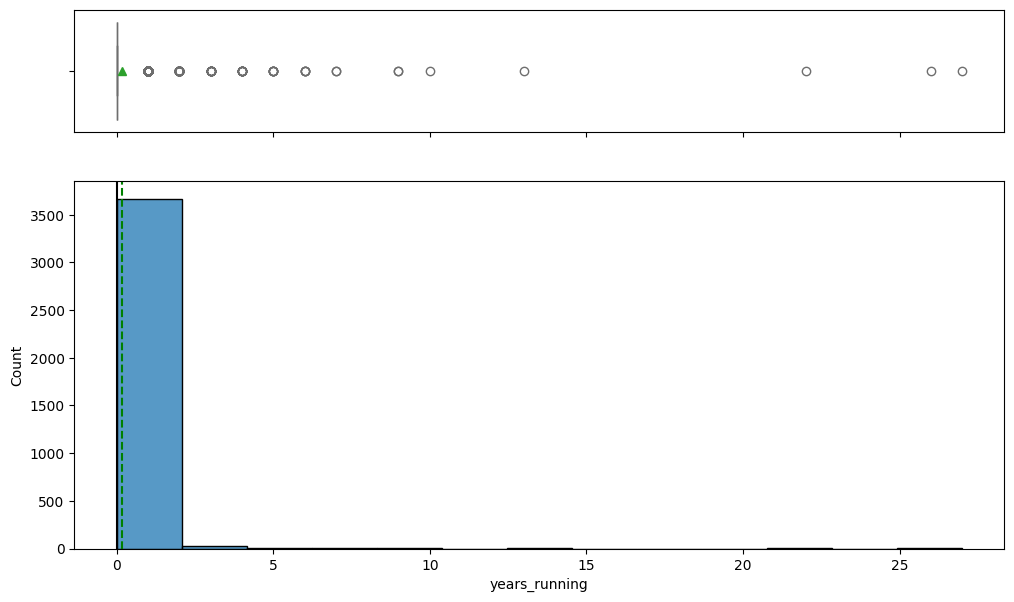

In [53]:
# years_running

histogram_boxplot(data, "years_running")

* The distribution is heavily right-skewed, and most of the anime have run for less than 1 year.

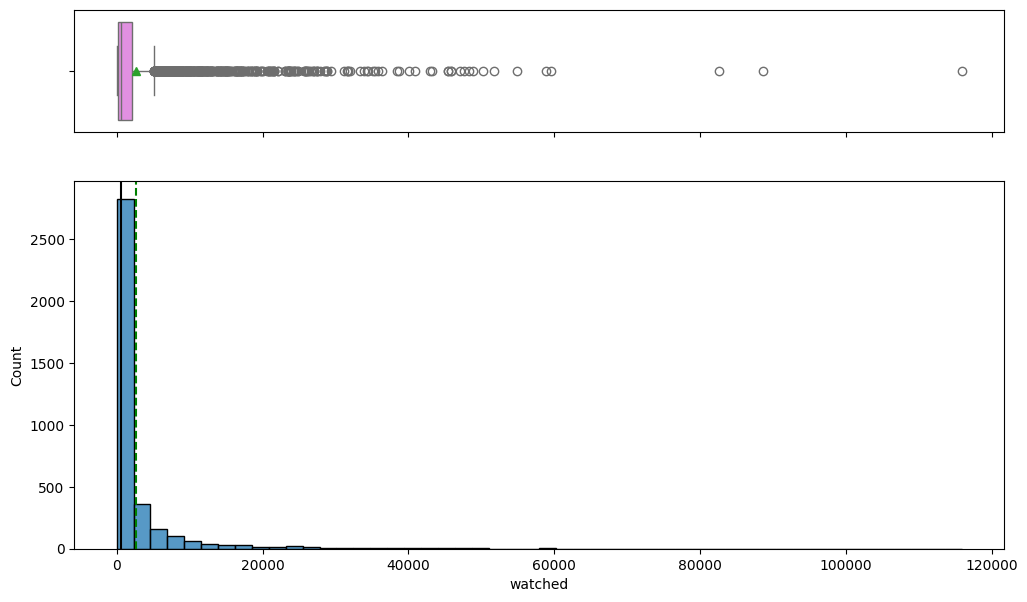

In [54]:
# watched

histogram_boxplot(data, "watched", bins=50)

* The distribution is heavily right-skewed, and most of the anime having less than 500 viewers.

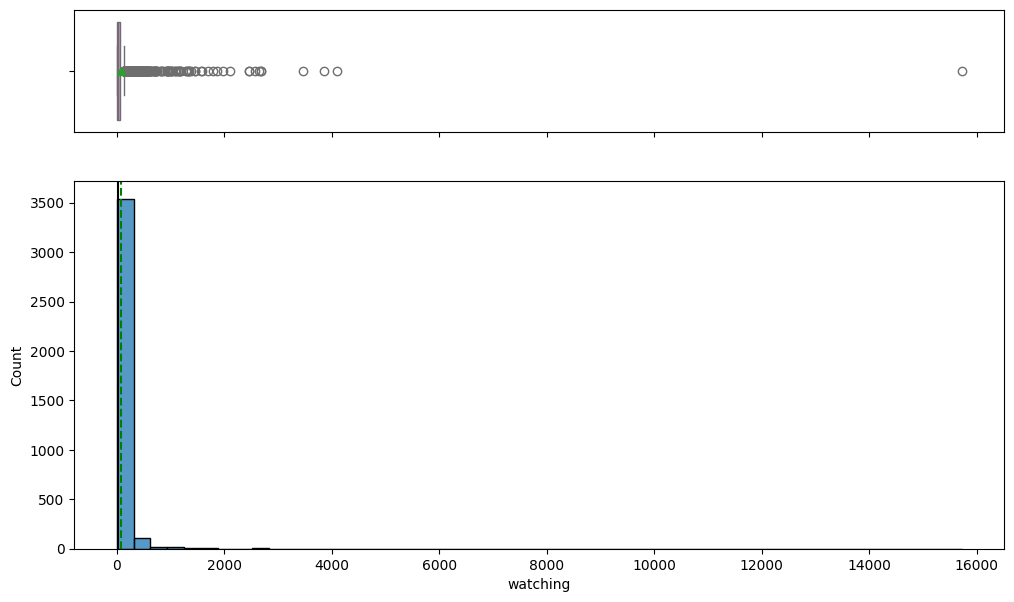

In [55]:
# watching

histogram_boxplot(data, "watching", bins=50)

* The distribution is heavily right-skewed.

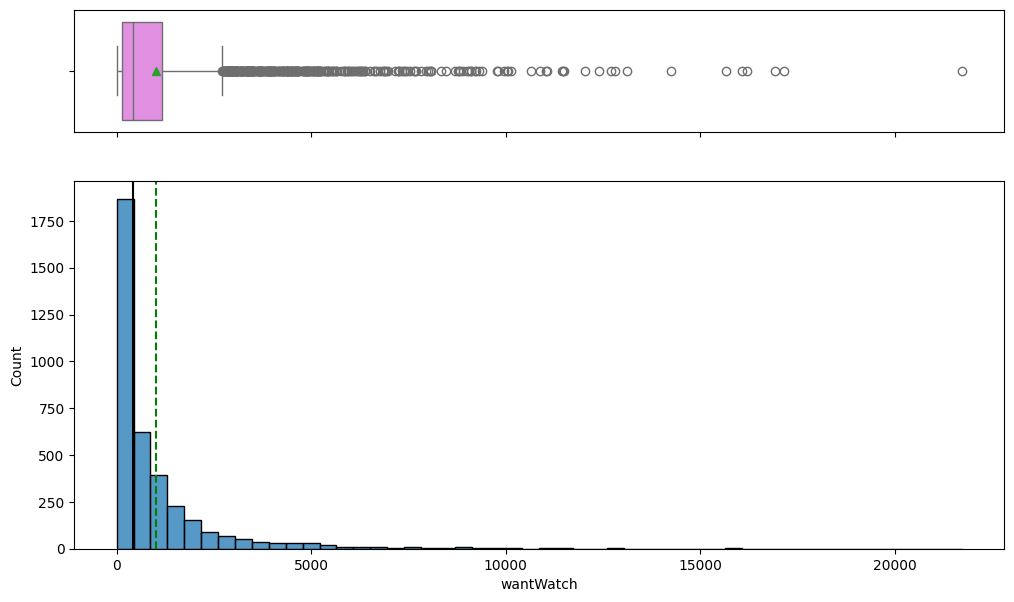

In [56]:
# wantWatch

histogram_boxplot(data, "wantWatch", bins=50)

* The distribution is heavily right-skewed.

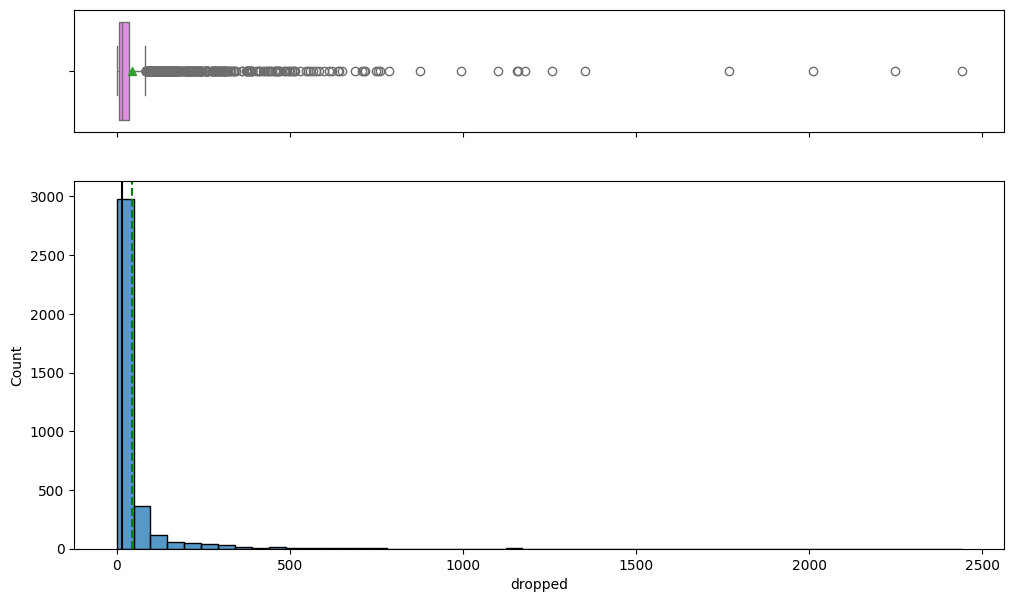

In [57]:
# dropped

histogram_boxplot(data, "dropped", bins=50)

* The distribution is heavily right-skewed.

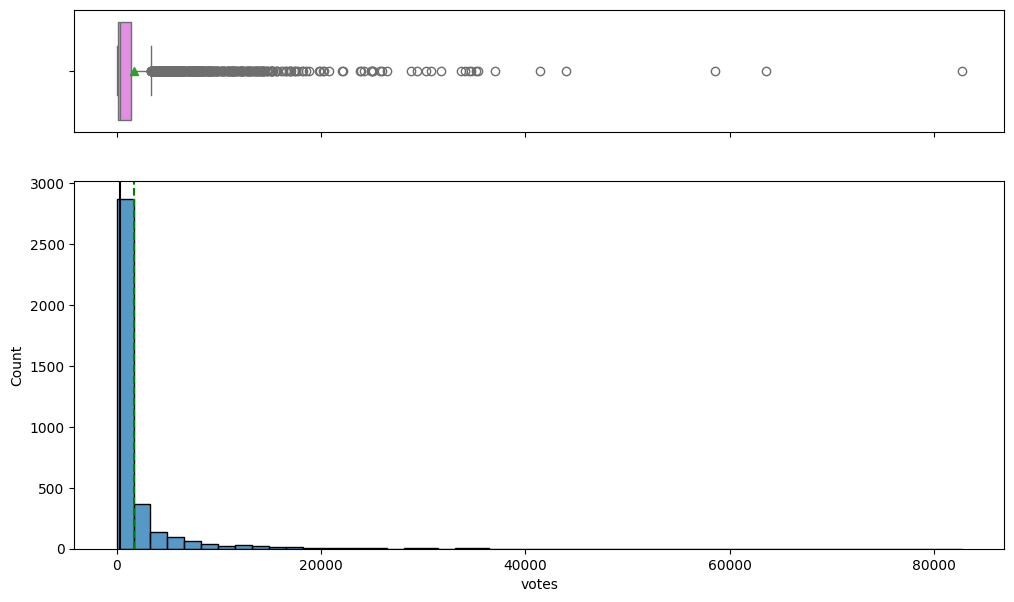

In [58]:
histogram_boxplot(data, "votes", bins=50)

* The distribution is heavily right-skewed, and few shows have more than 5000 votes.

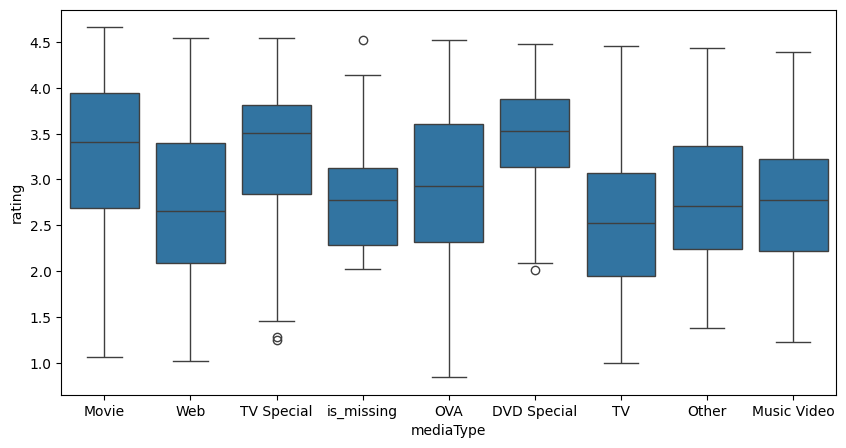

In [59]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="mediaType", y="rating", data=data)
plt.show()

* Anime available as TV series, web series, or music videos have a lower rating in general.
* watched and wantWatch columns are highly correlated.
* watched and votes columns are very highly correlated.
* wantWatch and votes columns are highly correlated.

Bivariate Analysis

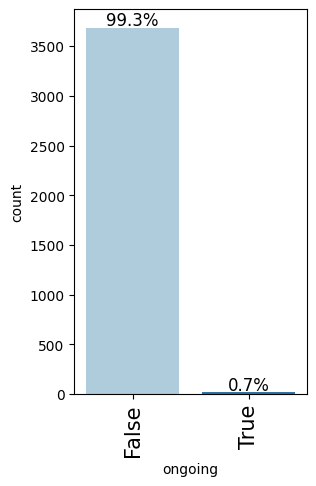

In [60]:
labeled_barplot(data, "ongoing", perc=True)

* Very few anime in the data are ongoing.

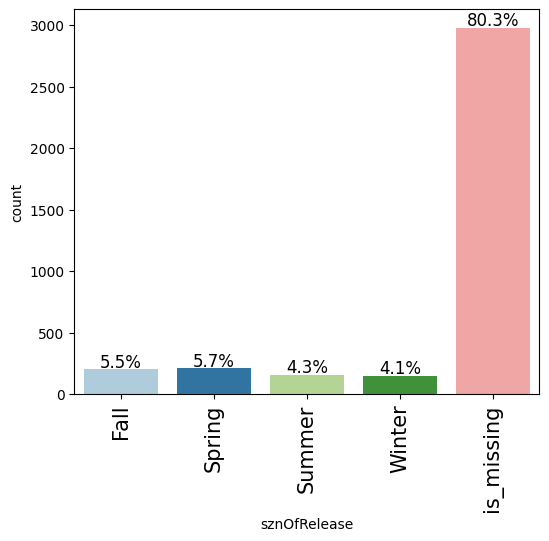

In [61]:
labeled_barplot(data, "sznOfRelease", perc=True)

* The season of release of anime is spread out across all seasons when the value is available.

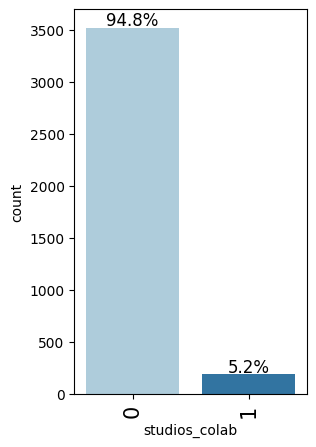

In [62]:
labeled_barplot(data, "studios_colab", perc=True)

* More than 95% of the anime in the data do not involve a collaboration between studios.

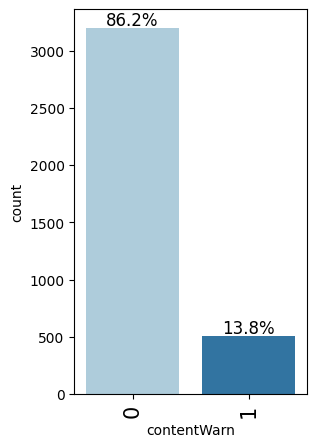

In [63]:
labeled_barplot(data, "contentWarn", perc=True)

* ~9% of the anime in the data have an associated content warning.

Creating a list of tags

In [65]:
tag_cols = [item for item in data.columns if "tag" in item]

for column in tag_cols:
    print(data[column].value_counts())
    print("-" * 50)

tag_Based_on_a_Manga
0    2495
1    1217
Name: count, dtype: int64
--------------------------------------------------
tag_Comedy
0    2635
1    1077
Name: count, dtype: int64
--------------------------------------------------
tag_Action
0    2767
1     945
Name: count, dtype: int64
--------------------------------------------------
tag_Fantasy
0    2992
1     720
Name: count, dtype: int64
--------------------------------------------------
tag_Sci_Fi
0    3025
1     687
Name: count, dtype: int64
--------------------------------------------------
tag_Shounen
0    3131
1     581
Name: count, dtype: int64
--------------------------------------------------
tag_Original_Work
0    3065
1     647
Name: count, dtype: int64
--------------------------------------------------
tag_Non_Human_Protagonists
0    3195
1     517
Name: count, dtype: int64
--------------------------------------------------
tag_Drama
0    3279
1     433
Name: count, dtype: int64
---------------------------------------------

* Most tag features are highly imbalanced, with 0 (tag absent) dominating.
* Based_on_a_Manga, Comedy, and Action are the most common tags.
* Fantasy, Sci_Fi, and Short_Episodes also have good representation.
* Tags like Mecha, Ecchi, Superpowers, and Based_on_a_Light_Novel are very rare.
* tag_missing has very few values, indicating minimal missing tag data.
* The dataset mainly contains mainstream anime genres/themes.
* Rare tags are sparse and may have lower impact in predictive modeling.

Correlation

In [69]:
# creating a list of non-tag columns
corr_cols = [item for item in data.columns if "tag" not in item]
print(corr_cols)

['mediaType', 'eps', 'duration', 'ongoing', 'sznOfRelease', 'years_running', 'studio_primary', 'studios_colab', 'contentWarn', 'watched', 'watching', 'wantWatch', 'dropped', 'rating', 'votes']


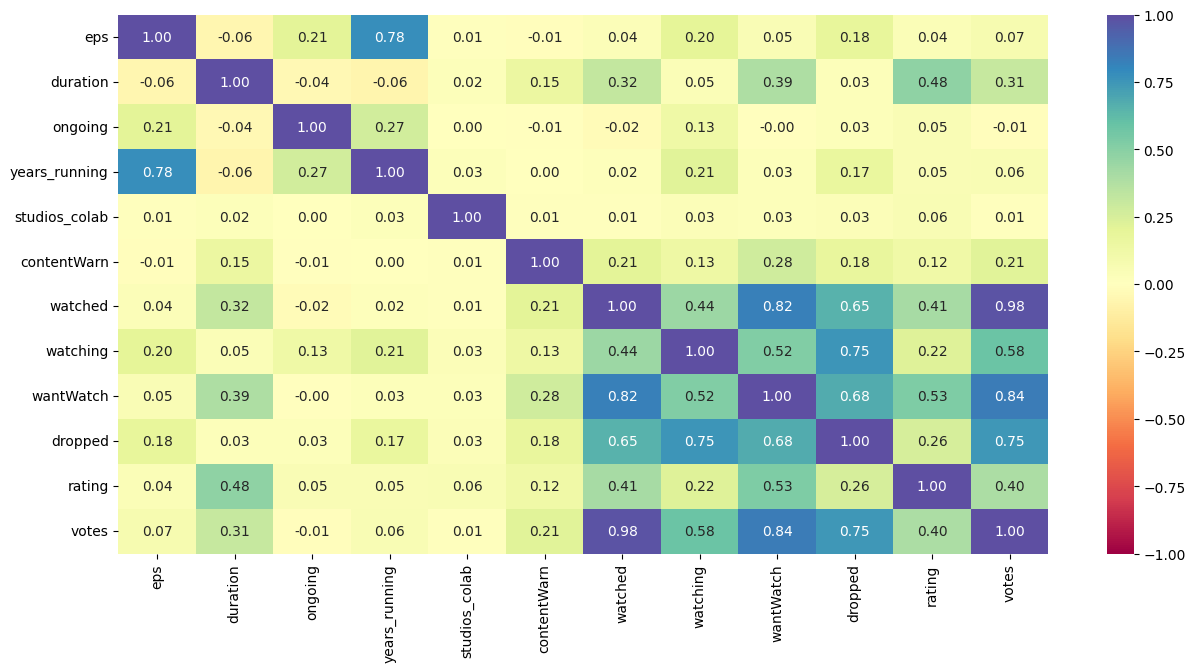

In [70]:
plt.figure(figsize=(15,7))
sns.heatmap(
    df[corr_cols].corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

<Figure size 2000x500 with 0 Axes>

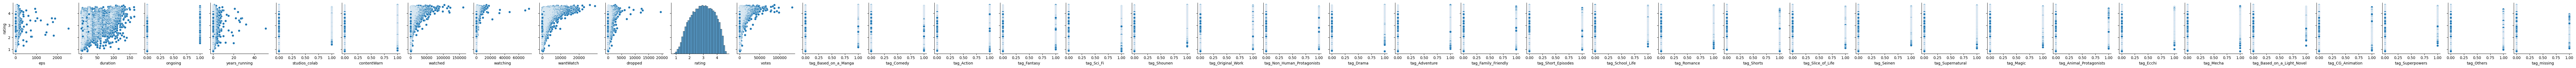

In [71]:
plt.figure(figsize=(20, 5))
sns.pairplot(df, y_vars="rating")
plt.show()

Studio_primary vs rating

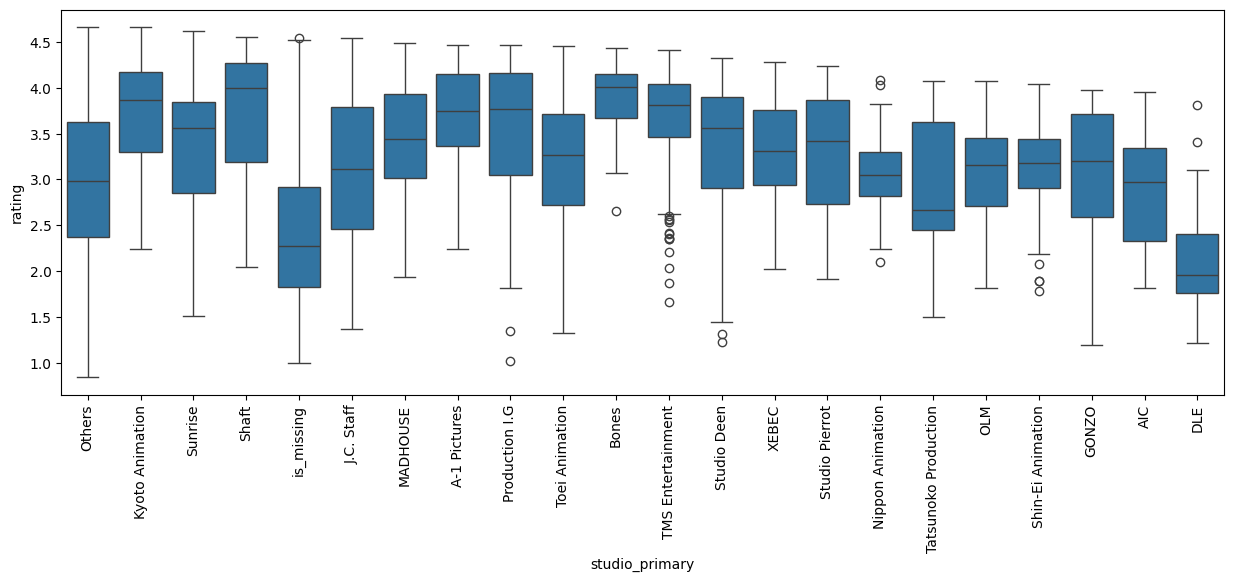

In [72]:
plt.figure(figsize=(15, 5))
sns.boxplot(x="studio_primary", y="rating", data=data)
plt.xticks(rotation=90)
plt.show()

* In general, the ratings are low for anime produced by DLE studios.
* Ratings are also low, in general, for anime produced by studios other than the ones in the data.